# Direct `<unk>` Diagnostic

This notebook investigates why the completed **SeamlessM4T v2-large Direct pipeline** produced literal `<unk>` tokens in some Simplified Chinese translations.

It does **not** modify the official Direct predictions and does **not** rerun speech translation.

It checks:

1. how many outputs contain `<unk>`;
2. whether the rate differs by accent group;
3. whether `<unk>` is associated with source length, audio duration, runtime, or generated-token count;
4. whether repeated source sentences show the same `<unk>` behaviour across speakers;
5. whether the SeamlessM4T tokenizer maps text in the Chinese reference translations to the actual unknown-token ID;
6. representative cases for manual inspection.

The official 4,200-sample run remains the baseline.


## 1. Install and import libraries

Only the SeamlessM4T processor/tokenizer is loaded. The large neural model is **not** required.


In [1]:
%pip install -q "transformers==4.57.6" sentencepiece pandas numpy matplotlib huggingface_hub ipywidgets protobuf sentencepiece


You should consider upgrading via the '/Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import transformers
from transformers import AutoProcessor

print("Transformers:", transformers.__version__)


/Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Transformers: 4.57.6


## 2. Resolve project paths

The code supports either `direct_full_run_1788151795` or `direct_run_1788151795`.
Edit the candidate paths if your local repository uses another name.


In [3]:
def find_project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, cwd.parent]:
        if (candidate / "data").exists() and (candidate / "runs").exists():
            return candidate
    return cwd

PROJECT_ROOT = find_project_root()

prediction_candidates = [
    PROJECT_ROOT / "runs/direct_full_run_1788151795/direct_predictions.csv",
    PROJECT_ROOT / "runs/direct_run_1788151795/direct_predictions.csv",
]

runtime_candidates = [
    PROJECT_ROOT / "runs/direct_full_run_1788151795/direct_runtime.csv",
    PROJECT_ROOT / "runs/direct_run_1788151795/direct_runtime.csv",
]

DIRECT_PREDICTIONS_PATH = next(
    (p for p in prediction_candidates if p.is_file()),
    prediction_candidates[0],
)

DIRECT_RUNTIME_PATH = next(
    (p for p in runtime_candidates if p.is_file()),
    runtime_candidates[0],
)

MODEL_ID = "facebook/seamless-m4t-v2-large"
MODEL_REVISION = "5f8cc790b19fc3f67a61c105133b20b34e3dcb76"

OUTPUT_DIR = PROJECT_ROOT / "runs" / f"direct_unk_diagnostic_{int(time.time())}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)

print("Project root:", PROJECT_ROOT)
print("Predictions:", DIRECT_PREDICTIONS_PATH)
print("Runtime:", DIRECT_RUNTIME_PATH)
print("Output:", OUTPUT_DIR)

if not DIRECT_PREDICTIONS_PATH.is_file():
    raise FileNotFoundError(
        f"Direct predictions not found: {DIRECT_PREDICTIONS_PATH}"
    )


Project root: /Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research
Predictions: /Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research/runs/direct_full_run_1788151795/direct_predictions.csv
Runtime: /Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research/runs/direct_full_run_1788151795/direct_runtime.csv
Output: /Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research/runs/direct_unk_diagnostic_1789953533


## 3. Load completed Direct predictions


In [4]:
pred = pd.read_csv(DIRECT_PREDICTIONS_PATH)

required = {
    "sentence",
    "sentence_id",
    "primary_accent",
    "sample_id",
    "reference_translation_zh",
    "direct_translation",
}

missing = required - set(pred.columns)
if missing:
    raise KeyError(f"Missing required columns: {sorted(missing)}")

if len(pred) != 4200:
    raise ValueError(f"Expected 4,200 rows, found {len(pred):,}")

pred = pred.copy()
pred["row_index"] = np.arange(len(pred))

pred["direct_has_unk"] = (
    pred["direct_translation"]
    .fillna("")
    .astype(str)
    .str.contains("<unk>", regex=False)
)

pred["direct_unk_count"] = (
    pred["direct_translation"]
    .fillna("")
    .astype(str)
    .str.count(re.escape("<unk>"))
)

print("Rows:", len(pred))
print("Rows containing <unk>:", int(pred["direct_has_unk"].sum()))
print("Rate:", f'{100 * pred["direct_has_unk"].mean():.2f}%')
print("Total literal <unk> occurrences:", int(pred["direct_unk_count"].sum()))


Rows: 4200
Rows containing <unk>: 508
Rate: 12.10%
Total literal <unk> occurrences: 599


## 4. Distribution of `<unk>` counts per output


In [5]:
unk_count_distribution = (
    pred["direct_unk_count"]
    .value_counts()
    .sort_index()
    .rename_axis("unk_tokens_in_output")
    .reset_index(name="clips")
)

display(unk_count_distribution)

unk_count_distribution.to_csv(
    OUTPUT_DIR / "unk_count_distribution.csv",
    index=False,
)


,unk_tokens_in_output,clips
0,0,3692
1,1,434
2,2,60
3,3,11
4,4,3


## 5. Descriptive `<unk>` rate by accent

This is descriptive only. It does not establish an accent effect because groups differ in speakers, sentence content, and recordings.


,primary_accent,clips,unk_clips,total_unk_tokens,unk_clip_rate_pct
0,England English,600,81,99,13.500000
3,"India and South Asia (India, Pakistan, Sri Lanka)",600,80,99,13.333333
4,Malaysian English,600,78,94,13.000000
6,United States English,600,76,83,12.666667
5,"Southern African (South Africa, Zimbabwe, Nami...",600,66,79,11.000000
1,Filipino,600,65,74,10.833333
2,Hong Kong English,600,62,71,10.333333


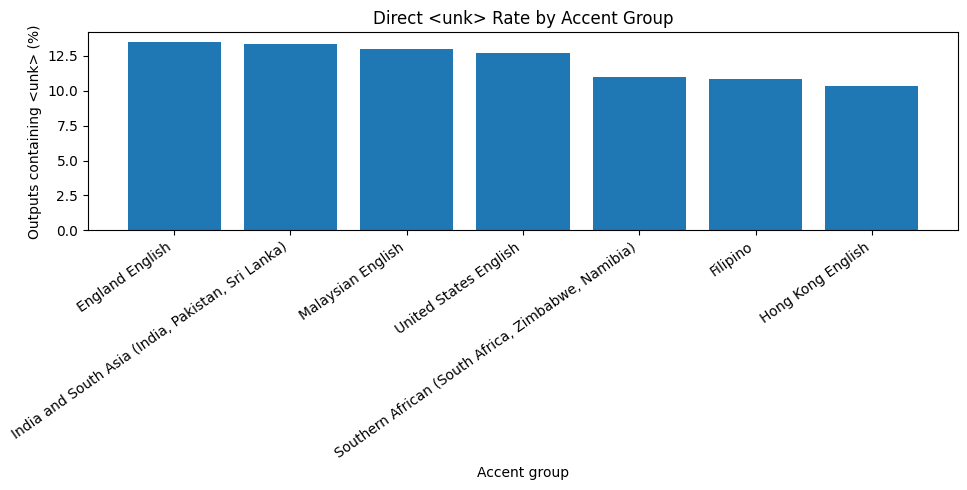

In [6]:
accent_summary = (
    pred.groupby("primary_accent", dropna=False)
    .agg(
        clips=("direct_has_unk", "size"),
        unk_clips=("direct_has_unk", "sum"),
        total_unk_tokens=("direct_unk_count", "sum"),
    )
    .reset_index()
)

accent_summary["unk_clip_rate_pct"] = (
    100 * accent_summary["unk_clips"] / accent_summary["clips"]
)

accent_summary = accent_summary.sort_values(
    "unk_clip_rate_pct",
    ascending=False,
)

display(accent_summary)

accent_summary.to_csv(
    OUTPUT_DIR / "accent_unk_summary.csv",
    index=False,
)

plt.figure(figsize=(10, 5))
plt.bar(
    accent_summary["primary_accent"],
    accent_summary["unk_clip_rate_pct"],
)
plt.ylabel("Outputs containing <unk> (%)")
plt.xlabel("Accent group")
plt.title("Direct <unk> Rate by Accent Group")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 6. Join runtime diagnostics

The earlier runtime file is aligned using `sample_index`, which corresponds to the row order of the official Direct run.


In [7]:
if DIRECT_RUNTIME_PATH.is_file():
    runtime = pd.read_csv(DIRECT_RUNTIME_PATH).copy()

    if "sample_index" not in runtime.columns:
        raise KeyError("Runtime CSV does not contain sample_index.")

    runtime["sample_index"] = pd.to_numeric(
        runtime["sample_index"],
        errors="coerce",
    ).astype("Int64")

    if runtime["sample_index"].isna().any():
        raise ValueError("Runtime CSV contains invalid sample_index values.")

    if runtime["sample_index"].duplicated().any():
        raise ValueError("Runtime CSV contains duplicate sample_index values.")

    keep = [
        c for c in [
            "sample_index",
            "audio_duration_sec",
            "direct_runtime_sec",
            "direct_generation_runtime_sec",
            "direct_realtime_factor",
            "generated_token_count",
            "generation_limit_reached",
            "direct_status",
        ]
        if c in runtime.columns
    ]

    pred = pred.merge(
        runtime[keep],
        left_on="row_index",
        right_on="sample_index",
        how="left",
        validate="one_to_one",
    )

    print("Runtime diagnostics joined.")
else:
    print("Runtime CSV not found. Runtime analysis will be skipped.")


Runtime diagnostics joined.


In [8]:
pred["source_word_count"] = (
    pred["sentence"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

candidate_measures = [
    "source_word_count",
    "audio_duration_sec",
    "direct_runtime_sec",
    "direct_generation_runtime_sec",
    "generated_token_count",
]

measures = [c for c in candidate_measures if c in pred.columns]

rows = []

for col in measures:
    values = pd.to_numeric(pred[col], errors="coerce")

    for flag, label in [(True, "contains_<unk>"), (False, "no_<unk>")]:
        subset = values[pred["direct_has_unk"] == flag].dropna()

        rows.append({
            "measure": col,
            "group": label,
            "n": len(subset),
            "mean": subset.mean(),
            "median": subset.median(),
            "std": subset.std(),
            "min": subset.min(),
            "max": subset.max(),
        })

numeric_summary = pd.DataFrame(rows)

display(numeric_summary)

numeric_summary.to_csv(
    OUTPUT_DIR / "unk_vs_nonunk_numeric_summary.csv",
    index=False,
)


,measure,group,n,mean,median,std,min,max
0,source_word_count,contains_<unk>,508,9.881890,10.000000,3.511299,2.000000,21.000000
1,source_word_count,no_<unk>,3692,8.862134,8.000000,3.592295,2.000000,26.000000
2,audio_duration_sec,contains_<unk>,508,5.047417,4.860000,1.696485,1.824000,9.360000
3,audio_duration_sec,no_<unk>,3692,4.560501,4.344000,1.662400,1.728000,9.384000
4,direct_runtime_sec,contains_<unk>,508,1.052853,0.985303,0.270867,0.664371,2.420101
5,direct_runtime_sec,no_<unk>,3692,0.911083,0.855187,0.234716,0.542248,2.144140
6,direct_generation_runtime_sec,contains_<unk>,508,1.020577,0.953449,0.262306,0.643862,2.351985
7,direct_generation_runtime_sec,no_<unk>,3692,0.880881,0.826161,0.226506,0.525718,2.069366
8,generated_token_count,contains_<unk>,508,19.370079,19.000000,5.153353,9.000000,42.000000
9,generated_token_count,no_<unk>,3692,14.325840,14.000000,4.770513,5.000000,36.000000


## 7. Repeated-sentence consistency

If the same source sentence is spoken by different speakers and repeatedly produces `<unk>`, this supports a content/model-related pattern more than a purely speaker-specific explanation.


In [9]:
repeated = (
    pred.groupby("sentence_id", dropna=False)
    .agg(
        occurrences=("sentence_id", "size"),
        speakers=("sample_id", "nunique"),
        accents=("primary_accent", "nunique"),
        unk_occurrences=("direct_has_unk", "sum"),
        sentence=("sentence", "first"),
    )
    .reset_index()
)

repeated = repeated[repeated["occurrences"] > 1].copy()

repeated["unk_rate"] = (
    repeated["unk_occurrences"] / repeated["occurrences"]
)

repeated["pattern"] = np.select(
    [
        repeated["unk_rate"].eq(0),
        repeated["unk_rate"].eq(1),
    ],
    [
        "never_unk",
        "always_unk",
    ],
    default="mixed",
)

pattern_counts = (
    repeated["pattern"]
    .value_counts()
    .rename_axis("pattern")
    .reset_index(name="repeated_sentences")
)

display(pattern_counts)

display(
    repeated[repeated["unk_occurrences"] > 0]
    .sort_values(["unk_rate", "occurrences"], ascending=[False, False])
    [
        [
            "sentence",
            "occurrences",
            "speakers",
            "accents",
            "unk_occurrences",
            "unk_rate",
            "pattern",
        ]
    ]
    .head(30)
)

repeated.to_csv(
    OUTPUT_DIR / "repeated_sentence_unk_summary.csv",
    index=False,
)


,pattern,repeated_sentences
0,never_unk,256
1,always_unk,43
2,mixed,2


,sentence,occurrences,speakers,accents,unk_occurrences,unk_rate,pattern
3344,The crowd swayed a little as I elbowed my way ...,5,5,4,5,1.0,always_unk
3832,He disappeared into the tent.,4,4,2,4,1.0,always_unk
215,"Yeah, I had a bit of a poke at that and failed...",3,3,3,3,1.0,always_unk
1023,He stood irresolute for a moment and then scra...,3,3,2,3,1.0,always_unk
3110,"He grew strawberries, so you would not like it.",3,3,3,3,1.0,always_unk
3476,"The Englishman prodded him, and the boy asked ...",3,3,3,3,1.0,always_unk
3494,But that was simply because my eye was tired.,3,3,3,3,1.0,always_unk
329,"Gossips are frogs, they drink and talk.",2,2,2,2,1.0,always_unk
781,Pull the hook to toggle the jukebox.,2,2,2,2,1.0,always_unk
1660,I have blisters on my hands because I was boul...,2,2,2,2,1.0,always_unk


## 8. Load the exact SeamlessM4T processor/tokenizer


In [17]:
processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    revision=MODEL_REVISION,
)

tokenizer = processor.tokenizer

print("Tokenizer class:", tokenizer.__class__.__name__)
print("UNK token:", tokenizer.unk_token)
print("UNK token ID:", tokenizer.unk_token_id)

if tokenizer.unk_token_id is None:
    raise ValueError("Tokenizer does not expose an unk_token_id.")


Tokenizer class: SeamlessM4TTokenizerFast
UNK token: <unk>
UNK token ID: 1


## 9. Check tokenizer coverage of the human Chinese references

This is a key diagnostic.

If the **human reference translation itself** contains the tokenizer's unknown-token ID after encoding, that is direct evidence that the tokenizer cannot normally represent some target text.

If references encode normally but generated sequences still produce `<unk>`, the problem is more likely generation/decoding behaviour.


In [19]:
def inspect_reference(text):
    text = "" if pd.isna(text) else str(text)

    encoded = tokenizer(
        text,
        add_special_tokens=False,
    )

    ids = list(encoded.input_ids)
    tokens = tokenizer.convert_ids_to_tokens(ids)

    unk_count = sum(
        int(token_id == tokenizer.unk_token_id)
        for token_id in ids
    )

    return {
        "reference_token_count": len(ids),
        "reference_tokenizer_unk_count": unk_count,
        "reference_tokenizer_has_unk": bool(unk_count),
        "reference_tokens": tokens,
    }


# Remove previously-created diagnostic columns if this cell is rerun.
diagnostic_columns = [
    "reference_token_count",
    "reference_tokenizer_unk_count",
    "reference_tokenizer_has_unk",
    "reference_tokens",
]

pred = pred.drop(
    columns=[
        col for col in diagnostic_columns
        if col in pred.columns
    ],
    errors="ignore",
)


# Run tokenizer inspection.
reference_info = pd.DataFrame(
    [
        inspect_reference(x)
        for x in pred["reference_translation_zh"]
    ],
    index=pred.index,
)


# Assign columns safely instead of concatenating.
for col in diagnostic_columns:
    pred[col] = reference_info[col]


# Sanity checks.
assert len(pred) == 4200
assert not pred.columns.duplicated().any()

print("Diagnostic columns added successfully.")

print(
    "Reference tokenizer contains UNK:",
    int(pred["reference_tokenizer_has_unk"].sum()),
    "/",
    len(pred),
)

print(
    "Direct output contains <unk>:",
    int(pred["direct_has_unk"].sum()),
    "/",
    len(pred),
)


# Cross-tabulation.
coverage = pd.crosstab(
    pred["reference_tokenizer_has_unk"],
    pred["direct_has_unk"],
    rownames=["Reference tokenizer contains UNK ID"],
    colnames=["Direct output contains literal <unk>"],
    margins=True,
)

display(coverage)


print(
    "Direct <unk> rows whose reference also tokenizes with UNK:",
    int(
        (
            pred["direct_has_unk"]
            & pred["reference_tokenizer_has_unk"]
        ).sum()
    ),
    "/",
    int(pred["direct_has_unk"].sum()),
)

Diagnostic columns added successfully.
Reference tokenizer contains UNK: 3498 / 4200
Direct output contains <unk>: 508 / 4200


Direct output contains literal <unk>,False,True,All
Reference tokenizer contains UNK ID,,,
False,642,60,702
True,3050,448,3498
All,3692,508,4200


Direct <unk> rows whose reference also tokenizes with UNK: 448 / 508


## 10. Inspect all affected rows


In [20]:
case_cols = [
    "row_index",
    "primary_accent",
    "sample_id",
    "sentence",
    "reference_translation_zh",
    "direct_translation",
    "direct_unk_count",
    "reference_tokenizer_unk_count",
    "reference_tokens",
]

affected = pred.loc[pred["direct_has_unk"], case_cols].copy()

display(affected.head(50))

affected.to_csv(
    OUTPUT_DIR / "all_direct_unk_rows.csv",
    index=False,
    encoding="utf-8-sig",
)


,row_index,primary_accent,sample_id,sentence,reference_translation_zh,direct_translation,direct_unk_count,reference_tokenizer_unk_count,reference_tokens
1,1,England English,spk_1385,"However, after persistent calls, Hall-Jones re...",然而，经过不断的电话，Hall-Jones 还是不情愿地接受了，尽管他在议会里毫无野心。,"然而,在持续的呼叫之后,霍尔-<unk>斯不情愿地接受了,尽管没有议会野心.",1,1,"[▁然而, ,, 经过, 不断, 的, 电话, ,, H, all, -, J, ones,..."
25,25,England English,spk_1516,He stood irresolute for a moment and then scra...,他犹豫不决地站了一会儿，然后从坑里爬了出来。,"他站不住了一会儿,然后<unk>出坑.",1,1,"[▁他, 犹, 豫, 不, 决, 地, 站, 了一, 会, 儿, ,, 然后, 从, 坑, ..."
30,30,England English,spk_1122,The river is tidal when it passes through Darg...,这条河流经达格维尔时会涨潮。,"当河流经过达尔加维尔时, 河流是潮<unk>的.",1,1,"[▁这, 条, 河, 流, 经, 达, 格, 维, 尔, 时, 会, 涨, 潮, <unk>]"
45,45,England English,spk_0383,The matter of the overall pennant was apparent...,至于整面旗帜的问题，显然还没有决定。,整体旗<unk>的问题显然从来没有决定过.,1,1,"[▁至, 于, 整, 面, 旗, 帜, 的问题, ,, 显然, 还没有, 决定, <unk>]"
76,76,England English,spk_0859,Stark naked. Under bare poles. In puris natura...,一丝不挂。光着身子。赤裸。,"在裸体,裸体<unk>下,在""自然纯粹""中.",1,3,"[▁一, 丝, 不, 挂, <unk>, 光, 着, 身, 子, <unk>, 赤, 裸, ..."
85,85,England English,spk_0996,Another reason why Apple is superior to Micros...,“苹果优于微软的另一个原因”，网络喷子为随后的网络争论战，准备了爆米花。,"""<unk>果优于微软的另一个原因"", 巨人发布并抓住了一些爆米花为随后的火焰战争.",1,3,"[▁, <unk>, 苹果, 优, 于, 微, 软, 的, 另一个, 原因, <unk>, ..."
88,88,England English,spk_0010,"Zora, can you teach me how to yodel?",Zora，你能教我约德尔唱法吗？,"佐拉,你能教我如何<unk>吗?",1,0,"[▁Z, ora, ,, 你, 能, 教, 我, 约, 德, 尔, 唱, 法, 吗, ?]"
89,89,England English,spk_1183,Restoration silver is characterized by embosse...,修复银的特点是压花图案表现的郁金香和自然的水果和树叶。,修复银的特点是<unk>花和自然的水果和叶子的雕刻图案.,1,1,"[▁, 修, 复, 银, 的特, 点, 是, 压, 花, 图, 案, 表现, 的, 郁, 金..."
113,113,England English,spk_1149,I have blisters on my hands because I was boul...,我手上起了水泡，因为我昨天抱石了。,"我手上有水泡,因为我昨天在<unk>岩.",1,1,"[▁我, 手, 上, 起, 了, 水, 泡, ,, 因为, 我, 昨, 天, 抱, 石, 了..."
124,124,England English,spk_1097,Where did you find that apple?,你在哪里找到那个苹果的？,你在哪里找到那个<unk>果?,1,0,"[▁你, 在, 哪里, 找到, 那个, 苹果, 的, ?]"


## 11. Optional manual Chinese tokenizer tests

Add suspicious Chinese words or characters here.


In [21]:
TEST_CHINESE_ITEMS = [
    "苹果",
    "骆驼",
    "帐篷",
    "旗帜",
    "草莓",
    "疲倦",
    "花生",
]

manual_rows = []

for text in TEST_CHINESE_ITEMS:
    ids = tokenizer(
        text,
        add_special_tokens=False,
    ).input_ids

    tokens = tokenizer.convert_ids_to_tokens(ids)

    manual_rows.append({
        "text": text,
        "token_ids": ids,
        "tokens": tokens,
        "contains_unk_id": tokenizer.unk_token_id in ids,
        "unk_id_count": sum(
            int(token_id == tokenizer.unk_token_id)
            for token_id in ids
        ),
    })

manual_df = pd.DataFrame(manual_rows)
display(manual_df)

manual_df.to_csv(
    OUTPUT_DIR / "manual_tokenizer_tests.csv",
    index=False,
    encoding="utf-8-sig",
)


,text,token_ids,tokens,contains_unk_id,unk_id_count
0,苹果,"[247661, 197441]","[▁, 苹果]",False,0
1,骆驼,"[247661, 254833, 254338, 0]","[▁, 骆, 驼, <pad>]",False,0
2,帐篷,"[247661, 253098, 254312, 0]","[▁, 帐, 篷, <pad>]",False,0
3,旗帜,"[247661, 251771, 254362, 0]","[▁, 旗, 帜, <pad>]",False,0
4,草莓,"[247661, 250865, 254341, 0]","[▁, 草, 莓, <pad>]",False,0
5,疲倦,"[247661, 252872, 253836, 0]","[▁, 疲, 倦, <pad>]",False,0
6,花生,"[95723, 248725]","[▁花, 生]",False,0


## 12. Save diagnostic summary


In [22]:
summary = {
    "input_predictions": str(DIRECT_PREDICTIONS_PATH),
    "input_runtime": (
        str(DIRECT_RUNTIME_PATH)
        if DIRECT_RUNTIME_PATH.is_file()
        else None
    ),
    "model_id": MODEL_ID,
    "model_revision": MODEL_REVISION,
    "tokenizer_class": tokenizer.__class__.__name__,
    "unk_token": tokenizer.unk_token,
    "unk_token_id": tokenizer.unk_token_id,
    "total_rows": int(len(pred)),
    "direct_unk_rows": int(pred["direct_has_unk"].sum()),
    "direct_unk_row_rate": float(pred["direct_has_unk"].mean()),
    "total_literal_unk_occurrences": int(pred["direct_unk_count"].sum()),
    "reference_rows_tokenizing_to_unk": int(
        pred["reference_tokenizer_has_unk"].sum()
    ),
    "direct_unk_rows_whose_reference_tokenizes_to_unk": int(
        (
            pred["direct_has_unk"]
            & pred["reference_tokenizer_has_unk"]
        ).sum()
    ),
    "repeated_sentence_pattern_counts": {
        str(row["pattern"]): int(row["repeated_sentences"])
        for _, row in pattern_counts.iterrows()
    },
    "interpretation_note": (
        "These are diagnostic associations. They do not prove that a single "
        "factor causes SeamlessM4T to generate <unk>."
    ),
}

(OUTPUT_DIR / "diagnostic_summary.json").write_text(
    json.dumps(summary, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print(json.dumps(summary, indent=2, ensure_ascii=False))
print("\nSaved to:", OUTPUT_DIR)


{
  "input_predictions": "/Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research/runs/direct_full_run_1788151795/direct_predictions.csv",
  "input_runtime": "/Users/nlh/Downloads/uoa_lectures/CS760/project/cs760-accent-st-robustness-ml-research/runs/direct_full_run_1788151795/direct_runtime.csv",
  "model_id": "facebook/seamless-m4t-v2-large",
  "model_revision": "5f8cc790b19fc3f67a61c105133b20b34e3dcb76",
  "tokenizer_class": "SeamlessM4TTokenizerFast",
  "unk_token": "<unk>",
  "unk_token_id": 1,
  "total_rows": 4200,
  "direct_unk_rows": 508,
  "direct_unk_row_rate": 0.12095238095238095,
  "total_literal_unk_occurrences": 599,
  "reference_rows_tokenizing_to_unk": 3498,
  "direct_unk_rows_whose_reference_tokenizes_to_unk": 448,
  "repeated_sentence_pattern_counts": {
    "never_unk": 256,
    "always_unk": 43,
    "mixed": 2
  },
  "interpretation_note": "These are diagnostic associations. They do not prove that a single factor causes SeamlessM4T to g

## Interpretation guide

- **References tokenize with UNK:** strong evidence of target-tokenizer coverage limitations.
- **References encode normally but generation still emits UNK:** more consistent with model-generation/decoding behaviour.
- **The same repeated sentence produces UNK across different speakers:** supports a content/model pattern more than a purely speaker-specific pattern.
- **Accent rates are similar:** do not present `<unk>` as an accent-specific result.

The official Direct outputs should remain unchanged.
